Bach Nguyen

# Mini Lab -- Image Clustering

## Assignment Setup (20 points)

Follow the setup steps below. 

1. Before doing anything, it is __strongly recommended__ that create a virtual environment for this project using `virtualenv` or `conda`. In the next step, we will be installing Tensorflow and Keras, and version control will be crucial. 

2. Using pip (not conda for this one), install the `tensorflow` and `keras` libraries. If you don't know how to specify a package version using pip, you can copy/paste the following code:

```
pip install tensorflow==2.13.0
pip install keras==2.13.1
```

__Note:__ I've tested this mini lab with `tensorflow` version 2.13.0 and `keras` 2.13.1, and it is compatible with both. It may well work with the latest version of `tensorflow` (2.16.1), but I haven't tested it. Keras 3 (the default on conda) will not work for this assignment. If you already have later versions of tensorflow or keras installed, you can downgrade or use a virtual environment to install the older versions.

3. Copy-paste the following import and test chunk:

```
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import glob 
import numpy as np
from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.applications.resnet50 import ResNet50
from keras.applications.vgg19 import VGG19
from keras.applications.mobilenet import MobileNet
import cv2
from sklearn.cluster import KMeans

tf.__version__ == '2.13.0'
keras.__version__ == '2.13.1'
```

Verify that the chunk returns `True True` before proceeding.

4. Copy/paste the following service functions to a code cell and run them. They should run without error.

```
def load_images_for_neural_network(fnames, batch_size):
    while True:
        cfns = []
        for i, p in enumerate(fnames):
            cfns.append(p)
            if len(cfns) == batch_size:
                yield load_images_keras(cfns)
                cfns = []
        if len(cfns) != 0:
            yield load_images_keras(cfns)
            cfns = []

def load_images_keras(image_list):
    images = []
    for i in image_list:
        this_pil = image.load_img(i, target_size = (224, 224))
        this_array = image.img_to_array(this_pil)
        c_img = np.expand_dims(this_array, axis = 0)
        images.append(c_img)
    return preprocess_input(np.vstack(images))
```

5. Load all segment images into Python using the service functions. You can copy/paste the following block of code:

```
bs = 64
segments = glob.glob("no-label-segments/*.png")
images_for_nn = load_images_for_neural_network(segments, batch_size=bs)
len(segments)
```

In [1]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import glob 
import numpy as np
import pandas as pd
from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.applications.resnet50 import ResNet50
from keras.applications.vgg19 import VGG19
from keras.applications.mobilenet import MobileNet
import cv2
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

tf.__version__ == '2.13.0'
keras.__version__ == '2.13.1'

True

In [4]:
def load_images_for_neural_network(fnames, batch_size):
    while True:
        cfns = []
        for i, p in enumerate(fnames):
            cfns.append(p)
            if len(cfns) == batch_size:
                yield load_images_keras(cfns)
                cfns = []
        if len(cfns) != 0:
            yield load_images_keras(cfns)
            cfns = []

def load_images_keras(image_list):
    images = []
    for i in image_list:
        this_pil = image.load_img(i, target_size = (224, 224))
        this_array = image.img_to_array(this_pil)
        c_img = np.expand_dims(this_array, axis = 0)
        images.append(c_img)
    return preprocess_input(np.vstack(images))

In [5]:
bs = 64
segments = glob.glob("no-label-segments/*.png")
images_for_nn = load_images_for_neural_network(segments, batch_size=bs)
len(segments)

6781

## Review: Images as Arrays 

In the last lab, we learned that we can use `opencv` to process image files into numpy arrays, where each pixel is either represented as a three-channel tuple of color values (like RGB) or a single channel of shade values (grayscale, thresholded). In the code cell above, `segments` is a list of file paths, and the function `load_images_for_neural_network` calls the `load_images_keras` function. Modify or pull out pieces of the `load_images_keras` function as needed to understand the following aspects of it:

- `image.load_img(i, target_size = (224, 224))`
- `image.img_to_array(this_pil)`
- `np.expand_dims(this_array, axis = 0)`
- `preprocess_input` 
- `np.vstack(images)`

Once you've completed writing code to understand these elements of the function, you can [Jump to Question 1](#Question-1)

---

## Loading a Pre-Trained Model

We can load a pre-trained model using keras/tensorflow as follows:

```
resnet_model = ResNet50(weights = 'imagenet', input_shape=(224,224,3), include_top=False, pooling='avg')
vgg19_model = VGG19(weights='imagenet', input_shape=(224,224,3), include_top=False, pooling='avg')
mobilenet_model = MobileNet(include_top=False, input_shape=(224,224,3), pooling='avg')
```

Copy/paste the above chunk to a code cell and run it. When this chunk runs without error, you will be ready to answer [Questions 2-4](#Question-2).

---

In [6]:
resnet_model = ResNet50(weights = 'imagenet', input_shape=(224,224,3), include_top=False, pooling='avg')
vgg19_model = VGG19(weights='imagenet', input_shape=(224,224,3), include_top=False, pooling='avg')
mobilenet_model = MobileNet(include_top=False, input_shape=(224,224,3), pooling='avg')

## Training Your Own Basic Model

Below is a `tensorflow` build for a very basic CNN model. Copy/paste these lines of code and verify that they run without error:

```
basic_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu') ])
```

After writing your code block and running the code, [Jump to Question 5](#Question-5)

---

In [7]:
basic_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu') ])

## Layers and Parameters

In one or more code chunks below, use the `.summary()` method to display summaries of the `resnet`, `vgg19`, and `mobilenet_model` models. Take a look at the layer-by-layer build of each pre-trained model and compare the results to the basic model above. After running the code, you can [Jump to Question 6](#Question-6)

---

In [29]:
resnet_model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [28]:
vgg19_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

 block3_conv1 (Conv2D)       (None, 56, 56, 256)       295168    
                                                                 
 block3_conv2 (Conv2D)       (None, 56, 56, 256)       590080    
                                                                 
 block3_conv3 (Conv2D)       (None, 56, 56, 256)       590080    
                                                                 
 block3_conv4 (Conv2D)       (None, 56, 56, 256)       590080    
                                                                 
 block3_pool (MaxPooling2D)  (None, 28, 28, 256)       0         
                                                                 
 block4_conv1 (Conv2D)       (None, 28, 28, 512)       1180160   
                                                                 
 block4_conv2 (Conv2D)       (None, 28, 28, 512)       2359808   
                                                                 
 block4_conv3 (Conv2D)       (None, 28, 28, 512)       2359808   
          

In [30]:
mobilenet_model.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 112, 112, 32

## Fitting Representations

The following code chunk will apply the `basic_model` transformation architecture to the `images_for_nn` set of images. The output of this code is stored as a variable called `basic_representations`. 

```
basic_representations = basic_model.predict(images_for_nn, steps=len(segments)/bs+1, verbose=1)
basic_representations = basic_representations[:len(segments),:]
```

Copy/paste the code chunk and inspect the `basic_representations` variable in any way that makes sense to you. When you feel like you understand the code reasonably well (including the second line of code), add to the code so you are also training similar representations sets for each of our models (`ResNet50`, `VGG19`, and `MobileNet`). Name your variables `ResNet50_representations`, `VGG19_representations`, and `MobileNet_representations` respectively. 

After writing your code block and running the code, [Jump to Question 7](#Question-7)

---

In [11]:
basic_representations = basic_model.predict(images_for_nn, steps=len(segments)/bs+1, verbose=1)
basic_representations = basic_representations[:len(segments),:]

106/106 [==============================] - 70s 661ms/step


In [12]:
resnet_representations = resnet_model.predict(images_for_nn, steps=len(segments)/bs+1, verbose=1)
resnet_representations = resnet_representations[:len(segments),:]

106/106 [==============================] - 201s 2s/step


In [13]:
vgg19_representations = vgg19_model.predict(images_for_nn, steps=len(segments)/bs+1, verbose=1)
vgg19_representations = vgg19_representations[:len(segments),:]

106/106 [==============================] - 468s 4s/step


In [14]:
mobilenet_representations = mobilenet_model.predict(images_for_nn, steps=len(segments)/bs+1, verbose=1)
mobilenet_representations = mobilenet_representations[:len(segments),:]

106/106 [==============================] - 55s 514ms/step


## K-Means Clustering 

Below is a little chunk of code that will train K-means clusters on the `basic_representations` data. 

```
KMM_basic = KMeans(n_clusters=200, random_state=12).fit(basic_representations)
cluster_predictions_basic = KMM_basic.labels_
```

Copy/paste the code chunk and inspect the `cluster_predictions_basic` variable in any way that makes sense to you. When you feel like you understand the code reasonably well, add to the code so that you are also fitting K-Means Models for the `ResNet50`, `VGG19`, and `MobileNet` representations. Name your variables `cluster_predictions_ResNet50`, `cluster_predictions_VGG19`, and `cluster_predictions_MobileNet` respectively. 

After writing your code block and running the code, [Jump to Question 8](#Question-8)

---

In [15]:
KMM_basic = KMeans(n_clusters=200, random_state=12).fit(basic_representations)
cluster_predictions_basic = KMM_basic.labels_

In [16]:
KMM_resnet = KMeans(n_clusters=200, random_state=12).fit(resnet_representations)
cluster_predictions_resnet = KMM_resnet.labels_

In [17]:
KMM_vgg19 = KMeans(n_clusters=200, random_state=12).fit(vgg19_representations)
cluster_predictions_vgg19 = KMM_vgg19.labels_

In [18]:
KMM_mobilenet = KMeans(n_clusters=200, random_state=12).fit(mobilenet_representations)
cluster_predictions_mobilenet = KMM_mobilenet.labels_

## Understanding the Results

K-Means clusters can be understood in several ways. We can start by understanding which images are grouped together and displaying them with an image grid but, to do so, we need to understand our cluster data and link it back to the source images it's describing. Using the `cluster_predictions_basic`, `cluster_predictions_ResNet50`, `cluster_predictions_VGG19`, and `cluster_predictions_MobileNet` variables, as well as the `segments` variable, construct a pandas `DataFrame` with the name of each image and its cluster assignment for each KMM. The output will look something like this:

|index | source_file | cluster_basic | cluster_ResNet50 | cluster_VGG19 | cluster_MobileNet |
|---|---|---|---|---|---|
|0| 'no-label-segments/19890625-3.png' | 17 | 26| 144 | 2 |

Name your pandas `DataFrame` variable `cluster_meta_all`. After writing your code block and running the code, [Jump to Questions 9 and 10](#Question-9)

---

In [19]:
cluster_meta = {'source_file': segments,
                'cluster_basic': cluster_predictions_basic,
                'cluster_ResNet50': cluster_predictions_resnet,
                'cluster_VGG19': cluster_predictions_vgg19,
                'cluster_MobileNet': cluster_predictions_mobilenet
}

cluster_meta_all = pd.DataFrame(cluster_meta)
cluster_meta_all.head()

,source_file,cluster_basic,cluster_ResNet50,cluster_VGG19,cluster_MobileNet
0,no-label-segments\19860105-18.png,28,71,199,49
1,no-label-segments\19860105-19.png,138,122,29,49
2,no-label-segments\19860105-21.png,18,192,171,49
3,no-label-segments\19860112-13.png,18,192,108,178
4,no-label-segments\19860112-15.png,18,71,108,95


## Worksheet Questions (8 points each)

### Question 1

Address the following in a markdown cell below:

- what is the purpose of `image.load_img(i, target_size = (224, 224))`?
- what is the purpose of `image.img_to_array(this_pil)`? 
- what is the purpose of `np.expand_dims(this_array, axis = 0)`?
- what does `preprocess_input` do? 
- what is the purpose of `np.vstack(images)`?

[Back to code block](#Review:-Images-as-Arrays)

- `image.load_img(i, target_size = (224, 224))`: This function loads an image file at the specified path i and resizes it to the target size of (224, 224). It is used to ensure consistency in input dimensions for deep learning models.
- `image.img_to_array(this_pil)`:  This function converts a PIL (Python Imaging Library) image this_pil into a numpy array representation. It essentially extracts the pixel data from the image, converting it into a numerical format that can be processed by machine learning algorithms.
- `np.expand_dims(this_array, axis = 0)`: This function expands the dimensions of the input array `this_array` along the specified axis (axis 0 in this case). It is used to add a batch dimension to the image array.
- `preprocess_input`: This function is used to preprocess a tensor or numpy array encoding a batch of images.
- `np.vstack(images)`: This function from numpy stacks arrays vertically, meaning it concatenates the arrays along the vertical axis (axis 0). In this context, it concatenates the preprocessed image arrays images into a single array.

### Question 2

Drawing on readings, the `tensorflow` and `keras` documentation, and any additional research you want to do, write a brief description of the `ResNet50` model, and the importance of the values the code block used for `weights`, `input_shape`, `include_top`, and `pooling` parameters. 

[Back to code block](#Loading-a-Pre-Trained-Model)

`ResNet50` is a deep convolutional neural network architecture proposed by Microsoft Research in 2015. It is part of the ResNet (Residual Network) family of models, which are renowned for their ability to train very deep neural networks effectively by addressing the vanishing gradient problem. The "50" in ResNet50 refers to the number of layers in the network, including convolutional layers, pooling layers, and fully connected layers.

- `weights`: This parameter specifies the weight initialization scheme to use for the model. The `'imagenet'` option indicates that the model should be initialized with pre-trained weights on the ImageNet dataset. 

- `input_shape`: This parameter defines the shape of the input images expected by the model. Therefore, `input_shape=(224, 224, 3)` indicates that the model expects input images to have this shape with RGB color channels.

- `include_top`: This parameter specifies whether to include the fully connected layers at the top of the network. Setting `include_top=False` indicates that the model should not include these layers, allowing for feature extraction from input images. 

- `pooling`: This parameter specifies the type of pooling operation to apply after the last convolutional layer. In this case, `'avg'` pooling is used, which computes the average value within each pooling window. This helps to reduce the spatial dimensions of the feature maps while preserving important spatial information.

### Question 3 

Drawing on readings, the `tensorflow` and `keras` documentation, and any additional research you want to do,  write a brief description of the `VGG19` model, and the importance of the values the code block used for `weights`, `input_shape`, `include_top`, and `pooling` parameters.

[Back to code block](#Loading-a-Pre-Trained-Model)

`VGG19` is a convolutional neural network architecture proposed by the Visual Geometry Group (VGG) at the University of Oxford. It was introduced in the paper "Very Deep Convolutional Networks for Large-Scale Image Recognition" by Karen Simonyan and Andrew Zisserman in 2014. VGG19 is an extension of the original VGG16 model, with 19 layers (hence the name) consisting mainly of convolutional and max-pooling layers.

- `weights`: This parameter specifies the weight initialization scheme to use for the model. Similar to ResNet50, the `'imagenet'` option indicates that the model should be initialized with pre-trained weights on the ImageNet dataset.

- `input_shape`: This parameter also define the shape of the input images expected by the model similar to `ResNet50`. Therefore, `input_shape=(224, 224, 3)` indicates the expected shape of input images: dimensions of 224x224 pixels and three color channels (RGB).

- `include_top`: This parameter specifies whether to include the fully connected layers at the top of the network. Setting `include_top=False` indicates that the model should not include these layers, allowing for feature extraction from input images. 

- `pooling`: This parameter specifies the type of pooling operation to apply after the last convolutional layer. In this case, `'avg'` pooling is used, which computes the average value within each pooling window. This helps to reduce the spatial dimensions of the feature maps while preserving important spatial information.

### Question 4

Drawing on readings, the `tensorflow` and `keras` documentation, and any additional research you want to do, write a brief description of the `MobileNet` model, and the importance of the values the code block used for `weights`, `input_shape`, `include_top`, and `pooling` parameters. 

[Back to code block](#Loading-a-Pre-Trained-Model)

`MobileNet` is a lightweight convolutional neural network architecture designed for mobile and embedded vision applications. It was introduced by Google researchers in the paper "MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications" by Andrew G. Howard et al. in 2017. MobileNet is characterized by its efficiency and small size, making it suitable for deployment on resource-constrained devices such as smartphones, IoT devices, and embedded systems.

- `weights`: This parameter specifies the weight initialization scheme to use for the model. Similar to ResNet50 and VGG19, the `'imagenet'` option indicates that the model should be initialized with pre-trained weights on the ImageNet dataset. 

- `input_shape`: This parameter also define the shape of the input images expected by the model similar to `ResNet50` and `VGG19`. Therefore, `input_shape=(224, 224, 3)` indicates the expected shape of input images: dimensions of 224x224 pixels and three color channels (RGB).

- `include_top`: This parameter specifies whether to include the fully connected layers at the top of the network. Setting `include_top=False` indicates that the model should not include these layers, allowing for feature extraction from input images. 

- `pooling`: This parameter specifies the type of pooling operation to apply after the last convolutional layer. In this case, `'avg'` pooling is used, which computes the average value within each pooling window. This helps to reduce the spatial dimensions of the feature maps while preserving important spatial information.

### Question 5

Drawing on readings, the `tensorflow` and `keras` documentation, and any additional research you want to do, write a summary summary of the basic model build demonstrated above. Address specifically what kinds of transformations the `Conv2D`, `MaxPooling2D`, and `Dropout` layers perform, as well as the importance of repeating this trio of layers three separate times. Lastly, address the importance of the `Flatten` and `Dense` layers at the end of the code chunk. 

[Back to code block](#Training-Your-Own-Basic-Model)

- `Conv2D`: This layer performs 2-dimensional convolutional operation on the input data. It applies a set of learnable filters to the input data to extract features. The parameters of the Conv2D layer include the number of filters (32, 32, and 64 in this case), the filter size (3x3), and the activation function ('relu').

- `MaxPooling2D`: This layer performs max pooling operation on the spatial dimensions of the input data. It reduces the spatial dimensions of the feature maps while retaining the most important information. The parameters specify the pool size (2x2) and the stride (2), which controls the amount of downsampling.

- `Dropout`: This layer applies dropout regularization to the input data, randomly setting a fraction of input units to zero during training. It helps prevent overfitting by reducing the interdependence between neurons. The parameter specifies the dropout rate (0.25), indicating the fraction of input units to drop during training.

- The trio of Conv2D, MaxPooling2D, and Dropout layers is repeated three times in the model. This repetition allows the network to learn increasingly complex features from the input data while reducing the spatial dimensions and preventing overfitting through dropout regularization.

- `Flatten`: This layer flattens the input data into a one-dimensional array. It converts the multi-dimensional feature maps obtained from the convolutional layers into a format suitable for input to the fully connected layers.

- `Dense`: This layer is a fully connected neural network layer. It connects every neuron in the previous layer to every neuron in the current layer. The Dense layer with 1024 units and 'relu' activation function provides a high-capacity representation of the learned features extracted by the convolutional layers, facilitating classification or regression tasks.

### Question 6

Compare and constrast the layer mixes of all three pre-trained models, as well as how they stack up to our basic model. Address the numbers of parameters displayed by the `summary()` methods, as well as the dimensionality or shape of the output for each model. Feel free to draw on readings, the `tensorflow` and `keras` documentation, and any additional research you want to do.

[Back to code block](#Layers-and-Parameters)

- `ResNet50` consists of convolutional layers followed by batch normalization and activation layers. It uses residual blocks to capture hierarchical features at different scales. The model gradually reduces the spatial dimensions using max-pooling layers. The output shape decreases in size as the model progresses, with the final layer producing a feature vector for classification.

- `VGG19` follows a simple architecture with alternating convolutional layers and max-pooling layers. It consists of multiple blocks of convolutional layers followed by max-pooling, with increasing depth as the model progresses. The model has a high number of parameters due to its deep architecture.

- `MobileNet` utilizes depthwise separable convolutions to reduce the number of parameters while maintaining efficiency. It consists of depthwise convolution layers followed by pointwise convolution layers and batch normalization. The model has significantly fewer parameters compared to `ResNet50` and `VGG19`, making it suitable for mobile and embedded applications.


### Question 7

- print the `shape` of `ResNet50_representations`, `VGG19_representations`, and `MobileNet_representations` below. 

[Back to code block](#Fitting-Representations)

In [20]:
print(basic_representations.shape, resnet_representations.shape, vgg19_representations.shape, mobilenet_representations.shape)

(6781, 1024) (6781, 2048) (6781, 512) (6781, 1024)


### Question 8

- print `KMM_basic.inertia_`, as well as the inertia_ values for the `KMM_ResNet50`, `KMM_VGG19`, and `KMM_MobileNet` models.

[Back to code block](#K-Means-Clustering)

In [21]:
print(KMM_basic.inertia_)

460971744.0


In [22]:
print(KMM_resnet.inertia_)

2448058.25


In [23]:
print(KMM_vgg19.inertia_)

12940491.0


In [24]:
print(KMM_mobilenet.inertia_)

1278995.875


### Question 9

- Display the first ten rows of the `cluster_meta_all` variable below.

[Back to code block](#Understanding-the-Results)

---

In [25]:
cluster_meta_all.head(10)

,source_file,cluster_basic,cluster_ResNet50,cluster_VGG19,cluster_MobileNet
0,no-label-segments\19860105-18.png,28,71,199,49
1,no-label-segments\19860105-19.png,138,122,29,49
2,no-label-segments\19860105-21.png,18,192,171,49
3,no-label-segments\19860112-13.png,18,192,108,178
4,no-label-segments\19860112-15.png,18,71,108,95
5,no-label-segments\19860112-7.png,12,71,71,143
6,no-label-segments\19860119-23.png,78,195,71,143
7,no-label-segments\19860119-27.png,38,195,40,96
8,no-label-segments\19860119-28.png,38,184,40,96
9,no-label-segments\19860119-29.png,38,76,106,188


### Question 10

- Adapting the sample code from the Github sandbox for the course, display image grids of one cluster from three different models. Use any criteria you would like for selecting the clusters to display. 


[Back to code block](#Collocations)

In [39]:
def load_cluster(df, max_n):
    cluster = []
    for e, i in df.iterrows():
        img = cv2.imread(i['source_file'])
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cluster.append(rgb)
        if e == max_n-1:
            break
    return cluster

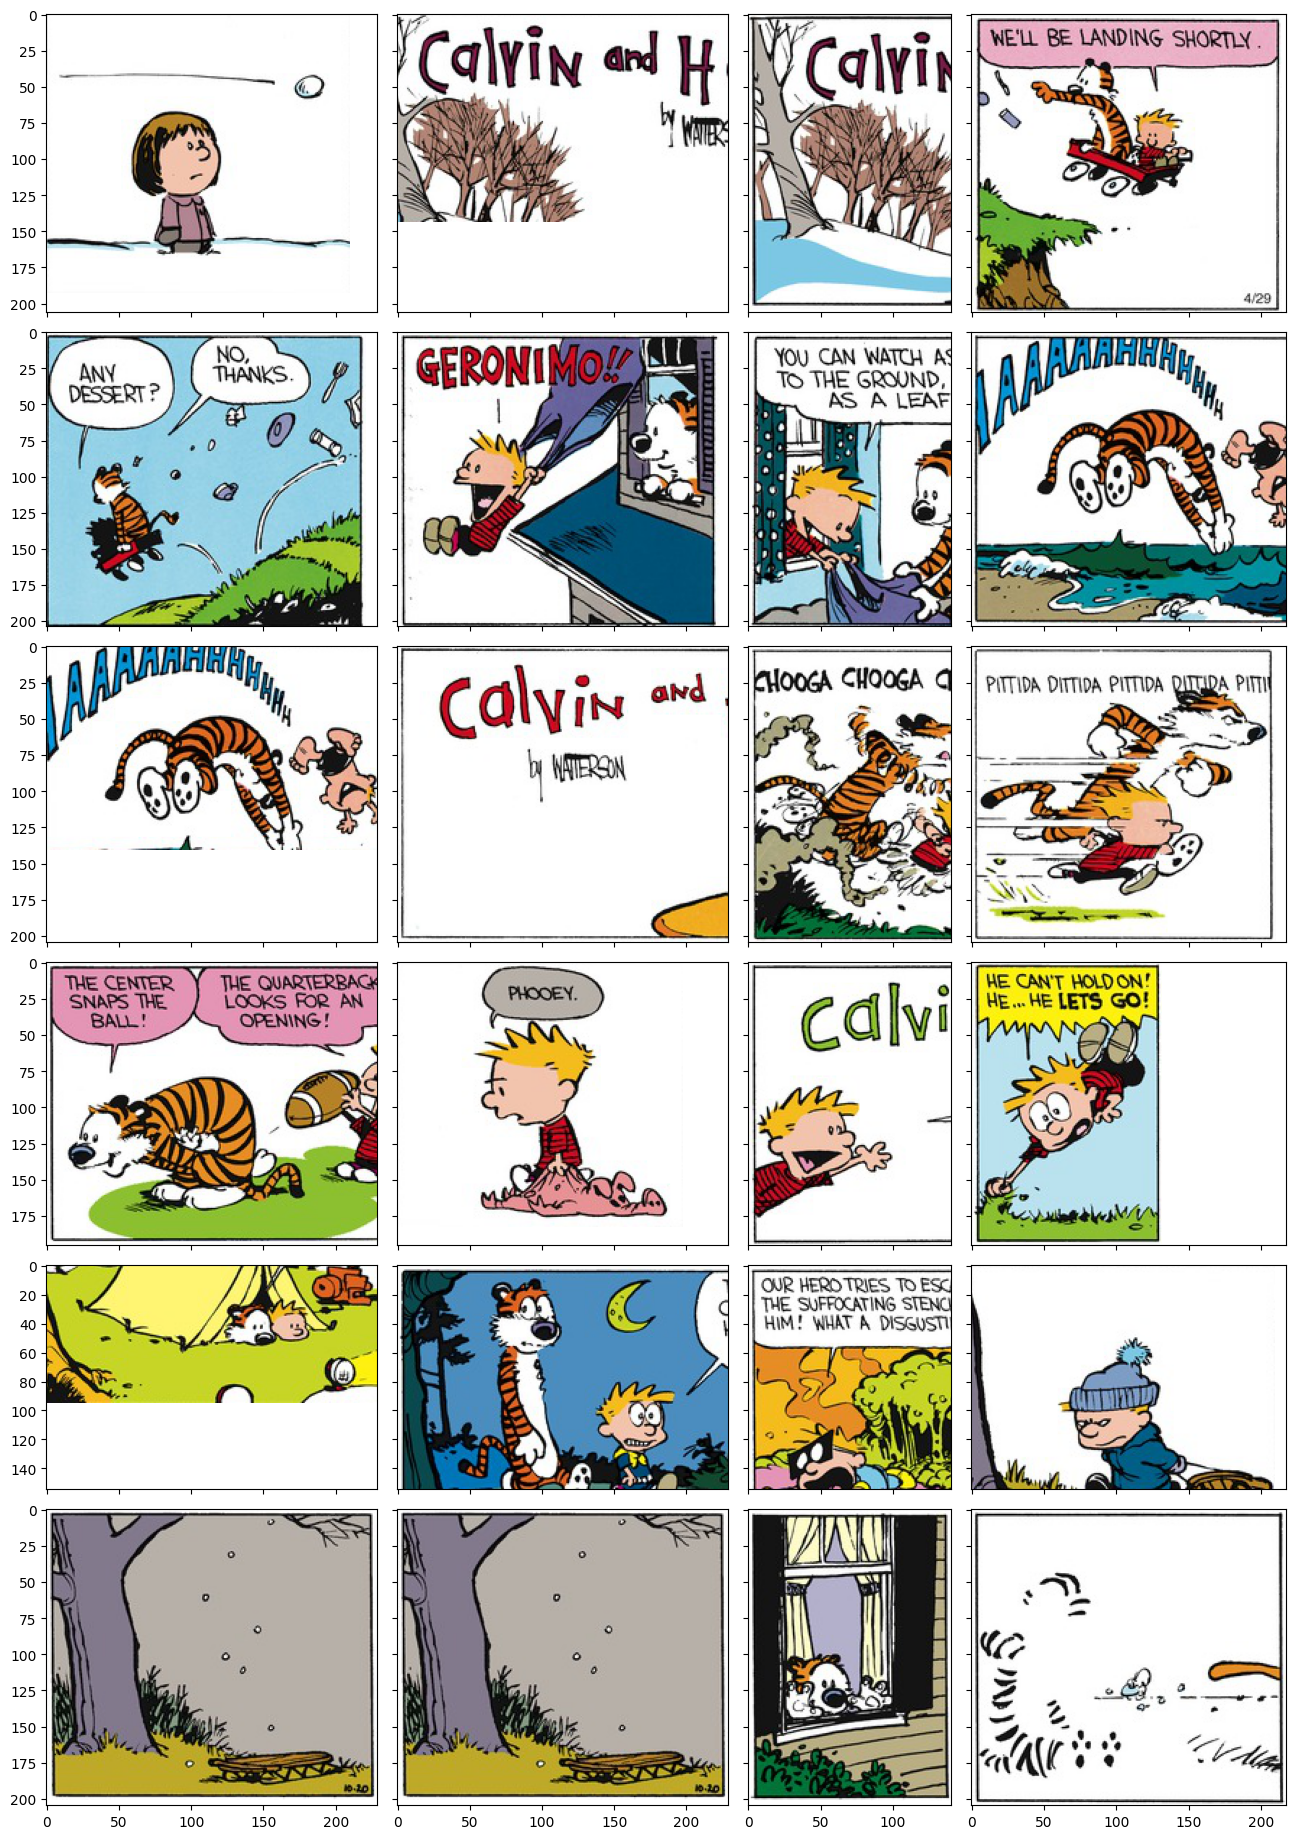

In [45]:
from mpl_toolkits.axes_grid1 import ImageGrid

cluster = load_cluster(cluster_meta_all.loc[cluster_meta_all['cluster_MobileNet'] == 49], 24)
fig = plt.figure(figsize=(16., 30.))
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                 nrows_ncols=(6, 4),  # creates Y x X grid of axes
                 axes_pad=0.2, # pad between axes in inch.
                 )

for ax, im in zip(grid, cluster):
    # Iterating over the grid returns the Axes.
    ax.imshow(im)

plt.show()

## Extra Credit (5 points max)

We can also perform a dimensionality reduction and view our cluster using a scatterplot. Take a stab at performing a PCA reduction of one of the `representations` variables. Take the first two dimensions, plot the results, and color the points in the plot to correspond with the cluster identities from one of your K-Means models. 

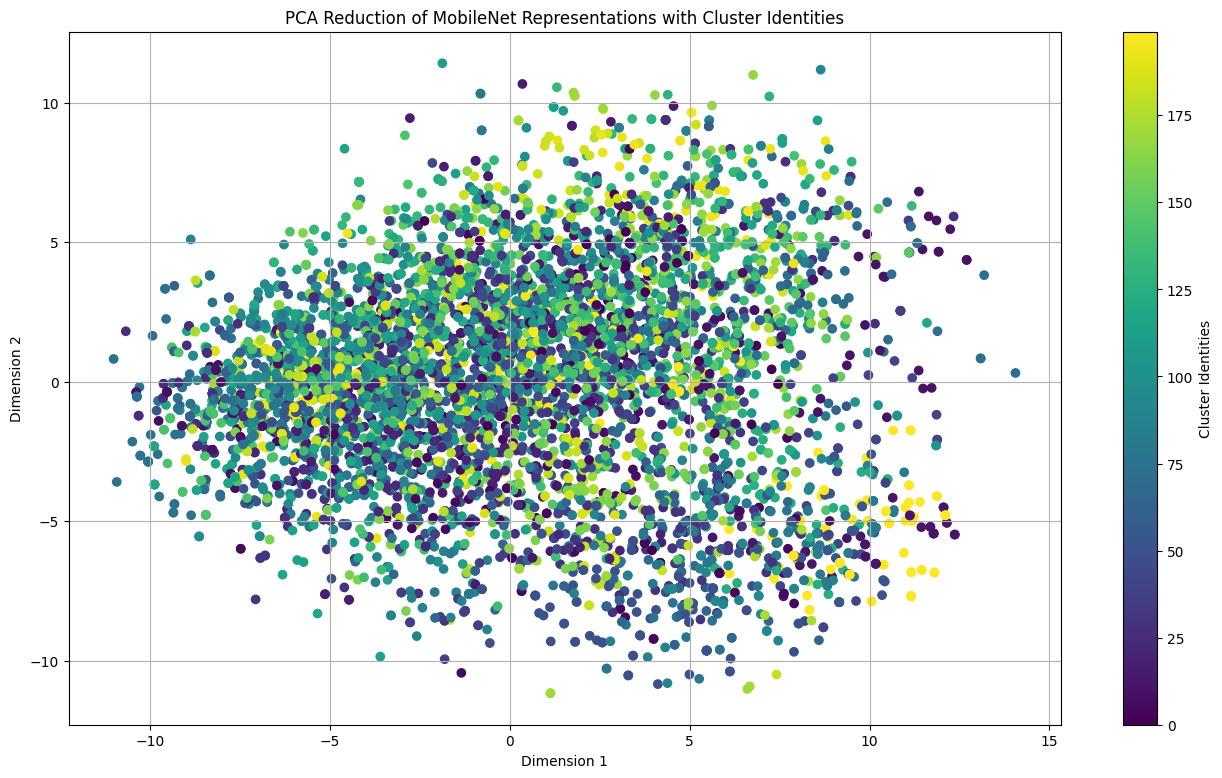

In [38]:
pca = PCA()
pca_result = pca.fit_transform(mobilenet_representations)

plt.figure(figsize=(16, 9))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_predictions_mobilenet)
plt.title('PCA Reduction of MobileNet Representations with Cluster Identities')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.colorbar(label='Cluster Identities')
plt.grid(True)
plt.show()
